### Main Dataset

In [29]:
import pandas as pd

# dataset
df = pd.read_csv("/home/aplior/Documents/Programming/Python/ASU-ASSIGNMENTS/Capstone/Data/UST/7fc13150-1dd2-4740-bfd1-6c9de62af18a-Ukraine_Support_Tracker_Release_24 - Bilateral Assistance, MAIN DATA.csv")

# drop empty columns
df = df.dropna(axis=1, how="all")

# Remove irrelevant columns
drop_cols = [col for col in df.columns if "debug" in col.lower() or "dummy" in col.lower()]
df = df.drop(columns=drop_cols)

# clean numeric columns
value_cols = [
    "source_reported_value", 
    "tot_activity_value", "tot_activity_value_EUR",
    "tot_sub_activity_value", "tot_sub_activity_value_EUR",
    "item_value_estimate_USD", "item_value_estimate_deliv_USD"
]

for col in value_cols:
    if col in df.columns:
        df[col] = (
            df[col]
            .astype(str)
            .str.replace(",", "", regex=False)
            .str.strip()
            .replace(["Not given", "Not Given", "Unknown", ""], pd.NA)
        )
        df[col] = pd.to_numeric(df[col], errors="coerce")

# standardize date column
if "announcement_date" in df.columns:
    df["announcement_date"] = pd.to_datetime(df["announcement_date"], errors="coerce")

# keep core analysis
core_cols = [
    "donor", "announcement_date", 
    "aid_type_general", "aid_type_specific",
    "explanation", "item", "item_type", "item_sub_type",
    "source_reported_value", "tot_activity_value_EUR", "item_value_estimate_USD"
]

df_clean = df[[col for col in core_cols if col in df.columns]]
df_clean


,donor,announcement_date,aid_type_general,aid_type_specific,explanation,item,item_type,item_sub_type,source_reported_value,tot_activity_value_EUR,item_value_estimate_USD
0,Australia,2022-03-01,Humanitarian,Equipment,Australia has committed immediate humanitarian...,.,.,.,35000000.0,23417160.0,NaN
1,Australia,2022-03-20,Humanitarian,Equipment,"A shipment of 70,000 tons of thermal coal has ...",ton of coal,Humanitarian,Humanitarian,32600000.0,21811412.0,23030000.0
2,Australia,2022-03-20,Humanitarian,Assistance,The Australian government announced 30 million...,.,.,.,12000000.0,8028741.0,NaN
3,Australia,2022-03-20,Humanitarian,Contribution,The Australian government announced 30 million...,.,.,.,10000000.0,6690617.0,NaN
4,Australia,2022-03-20,Humanitarian,Contribution,The Australian government announced 30 million...,.,.,.,8000000.0,5352494.0,NaN
...,...,...,...,...,...,...,...,...,...,...,...
4903,European Investment Bank,2024-07-22,Financial,Loan,The EIB Group has allocated EUR 86 million in ...,.,.,.,86000000.0,86000000.0,NaN
4904,European Investment Bank,2024-07-22,Financial,Guarantee,the EIB Group approved three partial portfolio...,.,.,.,110000000.0,110000000.0,NaN
4905,European Investment Bank,2024-09-24,Financial,Loan,The European Investment Bank (EIB) and the cit...,.,.,.,50000000.0,50000000.0,NaN
4906,European Investment Bank,2025-05-16,Financial,Loan,The European Investment Bank (EIB) has support...,.,.,.,511000.0,511000.0,NaN


In [30]:
#df_clean_2

In [31]:
#df_clean_merged = pd.concat([df_clean_1,df_clean_2], axis=1)

In [32]:
#df_clean_1.to_csv('core_COW.csv', index=False)
#df_clean_2.to_csv('values_COW.csv', index=False)
#df_clean_merged.to_csv('cleaned_COW.csv', index=False)

In [33]:
# grouppd
df_clean.groupby("aid_type_general")["tot_activity_value_EUR"].sum().sort_values(ascending=False)

aid_type_general
Military         1.929278e+11
Financial        1.925240e+11
Humanitarian     2.768613e+10
Humanitarian     5.200000e+06
Name: tot_activity_value_EUR, dtype: float64

In [34]:
df_clean["avg_commitment_value"] = (
    df_clean["tot_activity_value_EUR"] / df_clean.groupby("donor")["donor"].transform("count")
)

/home/aplior/miniconda3/envs/pynvim/lib/python3.7/site-packages/ipykernel_launcher.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  


In [35]:
# cool timeline test
timeline = (
    df_clean.groupby(df_clean["announcement_date"].dt.to_period("M"))["tot_activity_value_EUR"]
    .sum()
    .cumsum()
)
timeline

announcement_date
2022-01    2.668603e+08
2022-02    4.893503e+09
2022-03    1.641992e+10
2022-04    2.960881e+10
2022-05    4.118038e+10
2022-06    4.363683e+10
2022-07    4.773947e+10
2022-08    4.851530e+10
2022-09    6.932291e+10
2022-10    7.104470e+10
2022-11    7.273312e+10
2022-12    1.312815e+11
2023-01    1.332179e+11
2023-02    1.515362e+11
2023-03    1.549838e+11
2023-04    1.612024e+11
2023-05    1.754608e+11
2023-06    2.286463e+11
2023-07    2.302892e+11
2023-08    2.314926e+11
2023-09    2.338037e+11
2023-10    2.343582e+11
2023-11    2.404744e+11
2023-12    2.488339e+11
2024-01    2.528765e+11
2024-02    2.605367e+11
2024-03    2.608817e+11
2024-04    3.002664e+11
2024-05    3.096410e+11
2024-06    3.113643e+11
2024-07    3.173240e+11
2024-08    3.173907e+11
2024-09    3.185991e+11
2024-10    3.716147e+11
2024-11    3.721342e+11
2024-12    3.740262e+11
2025-01    3.749707e+11
2025-02    3.810566e+11
2025-03    3.837960e+11
2025-04    4.005076e+11
2025-05    4.011876e+1

In [36]:
# n largest donors with high EU
df_clean.nlargest(10, "tot_activity_value_EUR")

,donor,announcement_date,aid_type_general,aid_type_specific,explanation,item,item_type,item_sub_type,source_reported_value,tot_activity_value_EUR,item_value_estimate_USD,avg_commitment_value
4787,United States,2024-10-23,Financial,Loan,The United States announced that they will pro...,.,.,.,2.000000e+10,1.834131e+10,NaN,1.567633e+07
4865,EU (Commission and Council),2024-10-23,Financial,Loan,"On 23 October, the Council adopted a financial...",.,.,.,1.810000e+10,1.810000e+10,NaN,1.925532e+08
4820,EU (Commission and Council),2022-12-14,Financial,Loan,A new financial aid package of up to 18 billio...,.,.,.,1.800000e+10,1.800000e+10,NaN,1.914894e+08
4718,United States,2024-04-17,Military,Budgetary appropriations,$13.772 billion under Ukraine Security Assista...,.,.,.,1.377200e+10,1.283772e+10,NaN,1.097241e+07
4779,United States,2022-12-06,Financial,Budgetary appropriations,$13.37 billion in vital economic and budgetary...,.,.,.,1.337000e+10,1.262654e+10,NaN,1.079191e+07
3933,United States,2022-12-06,Military,Budgetary appropriations,Military Assistance increasing the Presidentia...,.,.,.,1.080000e+10,1.019945e+10,NaN,8.717476e+06
4624,United States,2022-12-06,Military,Budgetary appropriations,USD 9 billion under Ukraine Security Assistanc...,.,.,.,9.000000e+09,8.499539e+09,NaN,7.264563e+06
1822,Germany,2025-04-01,Military,Budgetary appropriations,"2026-2029 During a surprise visit to Kyiv, For...",.,.,.,8.250000e+09,8.250000e+09,NaN,1.434783e+07
4858,EU (Commission and Council),2023-06-20,Financial,Budgetary appropriations,"Loan Part, Ukraine Facility (2024): EU Commiss...",.,.,.,8.250000e+09,8.250000e+09,NaN,8.776596e+07
4874,EU (Commission and Council),2023-06-20,Financial,Budgetary appropriations,"Loan Part, Ukraine Facility (2025): EU Commiss...",.,.,.,8.250000e+09,8.250000e+09,NaN,8.776596e+07


In [37]:
# correlation test
df_clean[["tot_activity_value_EUR", "item_value_estimate_USD"]].corr()

,tot_activity_value_EUR,item_value_estimate_USD
tot_activity_value_EUR,1.00000,0.70354
item_value_estimate_USD,0.70354,1.00000


In [38]:
# unique aid types
df_clean.groupby("donor")["aid_type_general"].nunique()

donor
Australia                      2
Austria                        3
Belgium                        3
Bulgaria                       3
Canada                         3
China                          1
Croatia                        3
Cyprus                         3
Czechia                        2
Denmark                        3
EU (Commission and Council)    2
Estonia                        3
European Investment Bank       1
European Peace Facility        1
Finland                        3
France                         3
Germany                        3
Greece                         3
Hungary                        1
Iceland                        3
India                          1
Ireland                        3
Italy                          3
Japan                          3
Latvia                         3
Lithuania                      3
Luxembourg                     3
Malta                          1
Netherlands                    3
New Zealand                    3
Norw

Top 10 contributions by value (EUR):
                            donor announcement_date aid_type_general  \
4787                United States        2024-10-23        Financial   
4865  EU (Commission and Council)        2024-10-23        Financial   
4820  EU (Commission and Council)        2022-12-14        Financial   
4718                United States        2024-04-17         Military   
4779                United States        2022-12-06        Financial   
3933                United States        2022-12-06         Military   
4624                United States        2022-12-06         Military   
1822                      Germany        2025-04-01         Military   
4858  EU (Commission and Council)        2023-06-20        Financial   
4874  EU (Commission and Council)        2023-06-20        Financial   

             aid_type_specific  tot_activity_value_EUR  
4787                      Loan            1.834131e+10  
4865                      Loan            1.810000e+10  

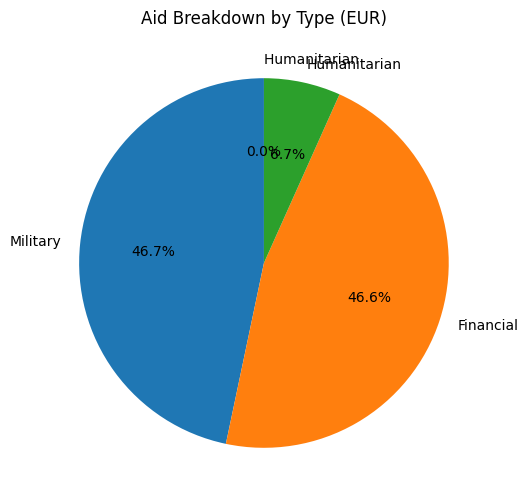

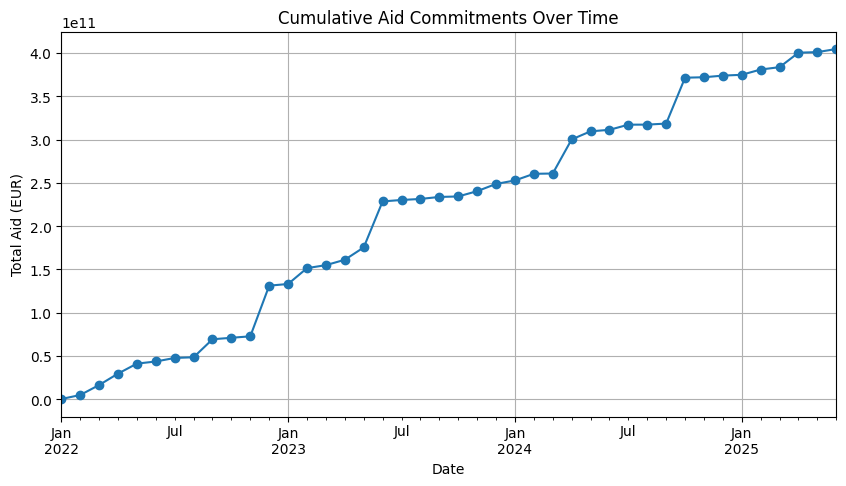

In [39]:
import matplotlib.pyplot as plt

# top n again
top10 = df_clean.nlargest(10, "tot_activity_value_EUR")

print("Top 10 contributions by value (EUR):")
print(top10[["donor", "announcement_date", "aid_type_general", 
              "aid_type_specific", "tot_activity_value_EUR"]])

# aid pie chart
aid_breakdown = (
    df_clean.groupby("aid_type_general")["tot_activity_value_EUR"]
    .sum()
    .sort_values(ascending=False)
)

plt.figure(figsize=(6,6))
aid_breakdown.plot.pie(autopct="%1.1f%%", startangle=90)
plt.title("Aid Breakdown by Type (EUR)")
plt.ylabel("")
plt.show()

# Timeline
timeline = (
    df_clean.groupby(df_clean["announcement_date"].dt.to_period("M"))["tot_activity_value_EUR"]
    .sum()
    .cumsum()
)

plt.figure(figsize=(10,5))
timeline.plot(marker="o")
plt.title("Cumulative Aid Commitments Over Time")
plt.xlabel("Date")
plt.ylabel("Total Aid (EUR)")
plt.grid(True)
plt.show()

In [40]:
# gouped by donor
aid_by_donor = (
    df_clean.groupby("donor")["tot_activity_value_EUR"]
    .sum()
    .reset_index()
)

aid_by_donor.columns = ["country", "total_aid_eur"]

In [41]:
# trying maps and stuff
import geopandas as gpd

world = gpd.read_file(gpd.datasets.get_path("naturalearth_lowres"))
# aid data to polys
world = world.merge(aid_by_donor, left_on="name", right_on="country", how="left")

In [42]:
from ipyleaflet import Map, GeoJSON
import json

# geodf to geoJSON
world_json = json.loads(world.to_json())

# styles :)
def style(feature):
    value = feature["properties"].get("total_aid_eur", 0) or 0
    if value > 1e9:  # > 1 billion
        color = "darkred"
    elif value > 1e8:  # > 100 million
        color = "red"
    elif value > 1e7:  # > 10 million
        color = "orange"
    elif value > 1e6:
        color = "yellow"
    else:
        color = "lightgray"
    return {
        "color": "black",
        "weight": 0.5,
        "fillColor": color,
        "fillOpacity": 0.7,
    }

# Create map
m = Map(center=(30,0), zoom=2)

geo_layer = GeoJSON(
    data=world_json,
    style_callback=style,
    hover_style={"fillColor": "blue", "fillOpacity": 0.8},
)

m.add_layer(geo_layer)
m

Map(center=[30, 0], controls=(ZoomControl(options=['position', 'zoom_in_text', 'zoom_in_title', 'zoom_out_text…

In [43]:
from ipywidgets import Output, VBox

info = Output()

def on_hover(event, feature, **kwargs):
    country = feature["properties"]["country"]
    total = feature["properties"].get("total_aid_eur", 0)
    with info:
        info.clear_output()
        print(f"{country}: €{total:,.0f}")

geo_layer.on_hover(on_hover)

ui = VBox([m, info])
ui

In [44]:
import geopandas as gpd
import pandas as pd
import json
from ipyleaflet import Map, GeoJSON, LayersControl
import matplotlib.cm as cm
import matplotlib.colors as colors

# world geos
world = gpd.read_file(gpd.datasets.get_path("naturalearth_lowres"))

# aid types
aid_types = ["Military", "Humanitarian", "Financial"]

# mapps
m = Map(center=(20, 0), zoom=2)

for aid_type in aid_types:
    # filter and aggregate
    aid_data = df_clean[df_clean["aid_type_general"] == aid_type]
    grouped = aid_data.groupby("donor")["tot_activity_value_EUR"].sum().reset_index()

    # merge with world geo
    merged = world.merge(grouped, left_on="name", right_on="donor", how="right")

    #color scale on values
    vals = merged["tot_activity_value_EUR"].dropna()
    if len(vals) > 0:
        norm = colors.Normalize(vmin=vals.min(), vmax=vals.max())
        cmap = cm.get_cmap("Blues")
    else:
        norm = None
        cmap = None

    styledict = {}
    for _, row in merged.iterrows():
        val = row["tot_activity_value_EUR"]
        if pd.isna(val) or norm is None:
            color = "#f0f0f0"
        else:
            rgba = cmap(norm(val))
            color = colors.rgb2hex(rgba)
        styledict[row["iso_a3"]] = {
            "color": "black",
            "weight": 1,
            "fillColor": color,
            "fillOpacity": 0.7 if not pd.isna(val) else 0.3
        }

    # geod to geoJSON
    geo_json = json.loads(merged.to_json())

    # add layer
    gj = GeoJSON(
        data=geo_json,
        style_callback=lambda feature: styledict.get(feature["id"], {}),
        name=f"{aid_type} Aid"
    )
    m.add_layer(gj)

# add layer controls
m.add_control(LayersControl(position="topright"))

m

Map(center=[20, 0], controls=(ZoomControl(options=['position', 'zoom_in_text', 'zoom_in_title', 'zoom_out_text…

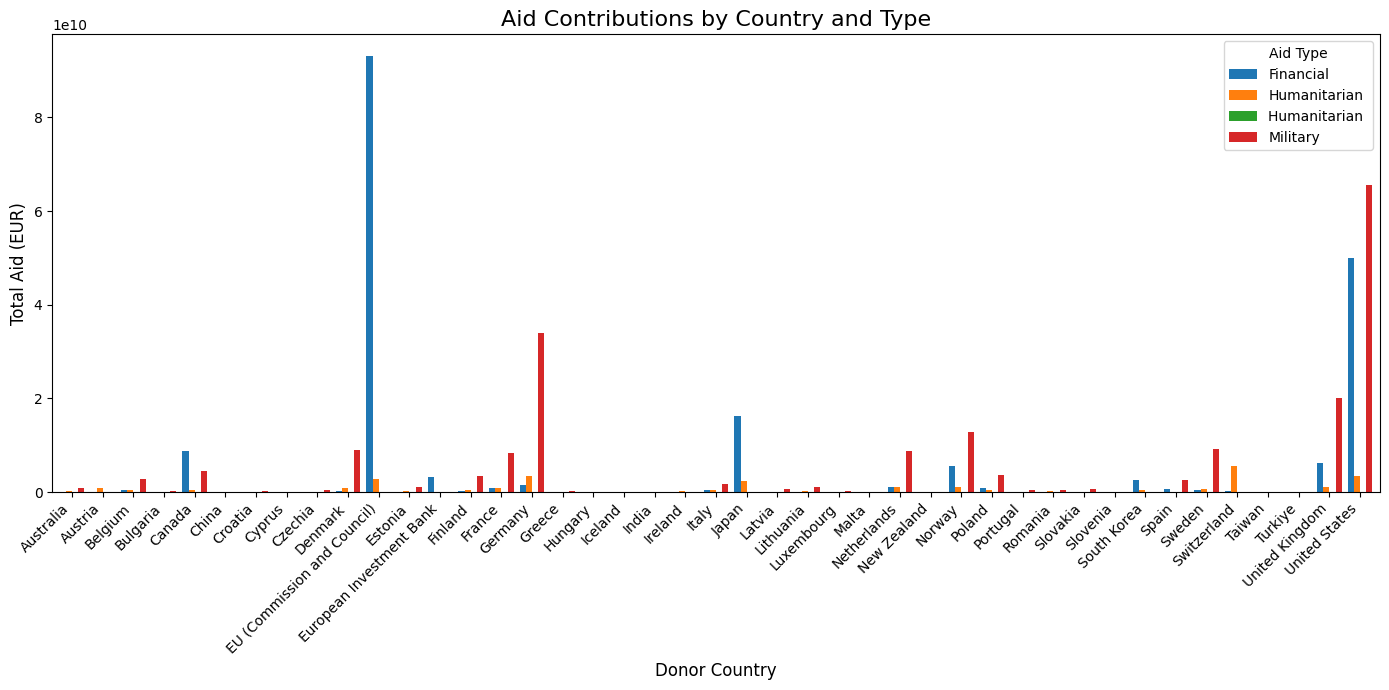

In [45]:
import pandas as pd
import matplotlib.pyplot as plt

# dataset
df = df_clean

# numeric columns
value_col = "tot_activity_value_EUR"
df[value_col] = (
    df[value_col]
    .astype(str)
    .str.replace(",", "", regex=False)
    .str.strip()
    .replace(["Not given", "Not Given", "Unknown", ""], pd.NA)
)
df[value_col] = pd.to_numeric(df[value_col], errors="coerce")

# drop rows and jazz
df_plot = df.dropna(subset=["aid_type_general", value_col])

# group
grouped = df_plot.groupby(["donor", "aid_type_general"])[value_col].sum().unstack(fill_value=0)

# plot
ax = grouped.plot(
    kind="bar",
    figsize=(14, 7),
    width=0.8
)

# more plot
plt.title("Aid Contributions by Country and Type", fontsize=16)
plt.ylabel("Total Aid (EUR)", fontsize=12)
plt.xlabel("Donor Country", fontsize=12)
plt.xticks(rotation=45, ha="right")
plt.legend(title="Aid Type")
plt.tight_layout()

plt.show()

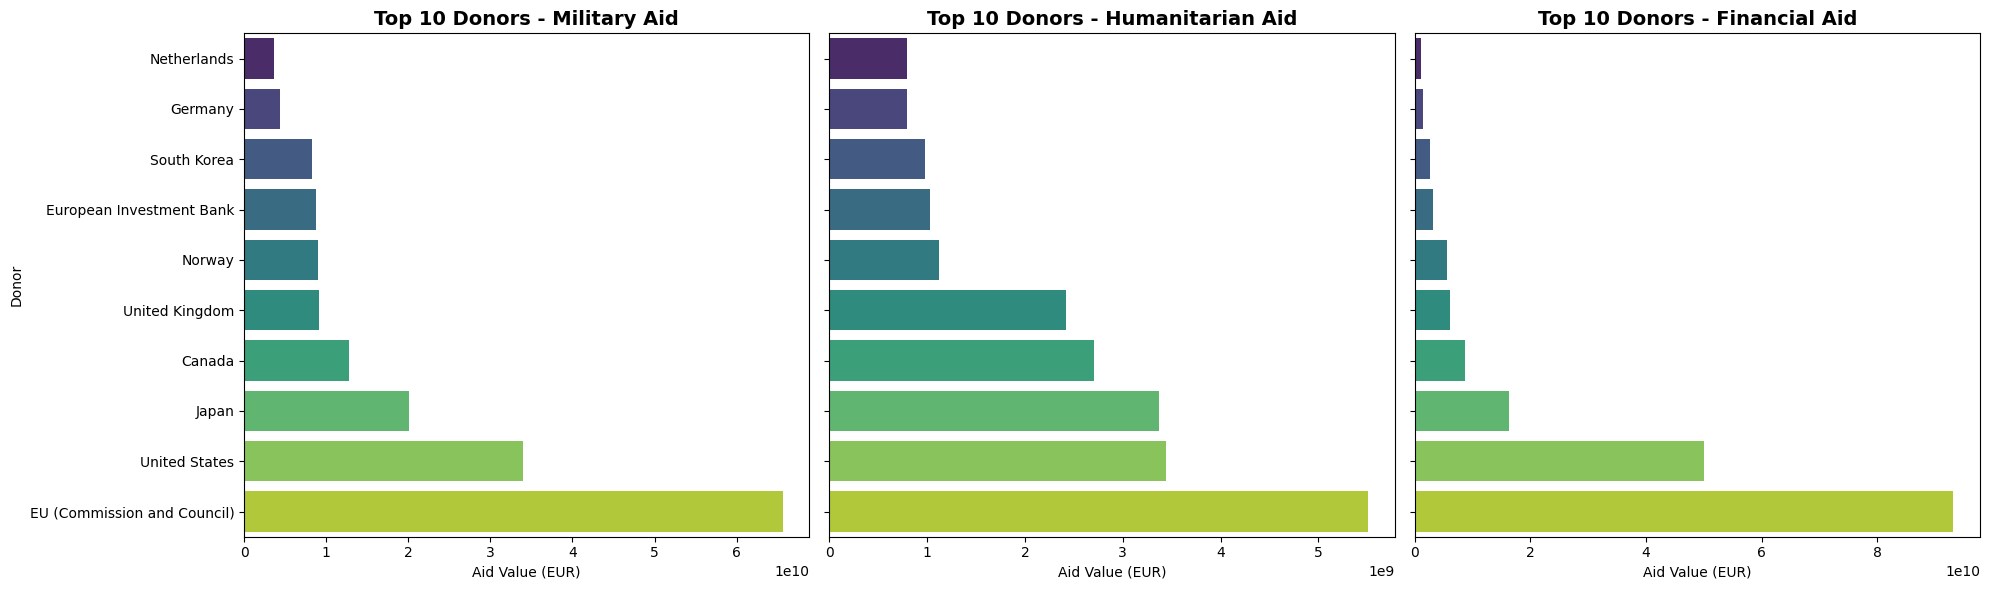

In [46]:
import matplotlib.pyplot as plt
import seaborn as sns

# group
grouped = (
    df_clean.groupby(["donor", "aid_type_general"])["tot_activity_value_EUR"]
    .sum()
    .reset_index()
)

# make subplots
aid_types = ["Military", "Humanitarian", "Financial"]
fig, axes = plt.subplots(1, 3, figsize=(20, 6), sharey=True)

for i, aid_type in enumerate(aid_types):
    # filterin
    subset = grouped[grouped["aid_type_general"] == aid_type]
    top10 = subset.nlargest(10, "tot_activity_value_EUR").sort_values("tot_activity_value_EUR", ascending=True)

    # plot horizontals
    sns.barplot(
        data=top10,
        x="tot_activity_value_EUR",
        y="donor",
        ax=axes[i],
        palette="viridis"
    )

    # plot stuff
    axes[i].set_title(f"Top 10 Donors - {aid_type} Aid", fontsize=14, weight="bold")
    axes[i].set_xlabel("Aid Value (EUR)")
    axes[i].set_ylabel("Donor" if i == 0 else "")  # only first subplot shows y-label

plt.tight_layout()
plt.show()


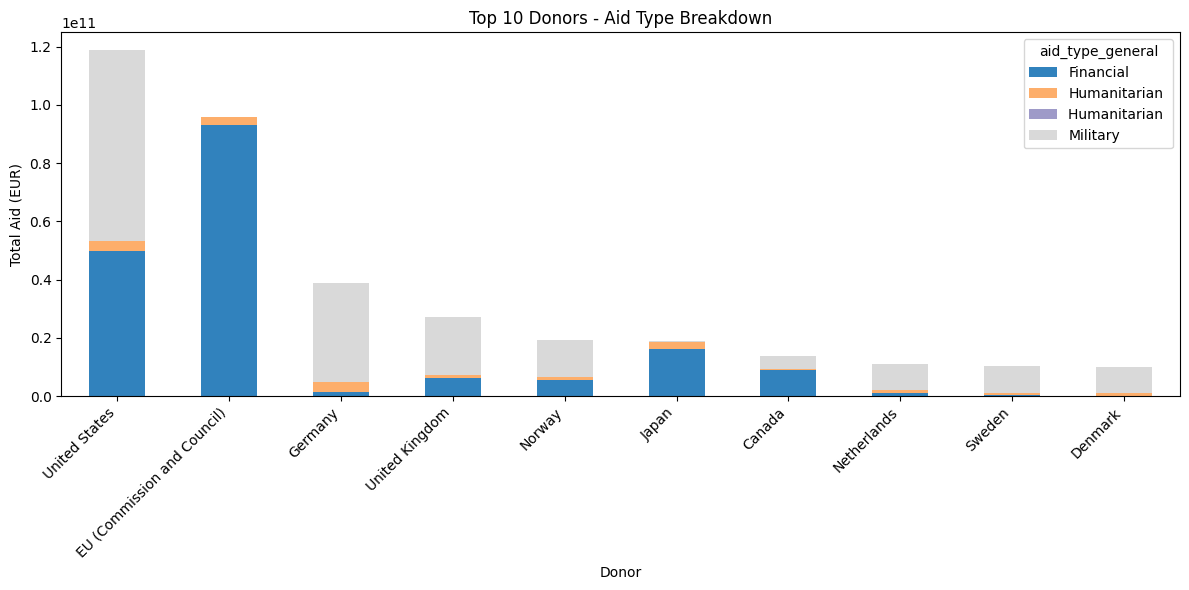

In [47]:
# group again
aid_breakdown = (
    df_clean.groupby(["donor", "aid_type_general"])["tot_activity_value_EUR"]
    .sum().unstack(fill_value=0)
)

# top n largest
aid_breakdown_top = aid_breakdown.loc[aid_breakdown.sum(axis=1).nlargest(10).index]

# plot
aid_breakdown_top.plot(kind="bar", stacked=True, figsize=(12,6), colormap="tab20c")
plt.title("Top 10 Donors - Aid Type Breakdown")
plt.ylabel("Total Aid (EUR)")
plt.xlabel("Donor")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

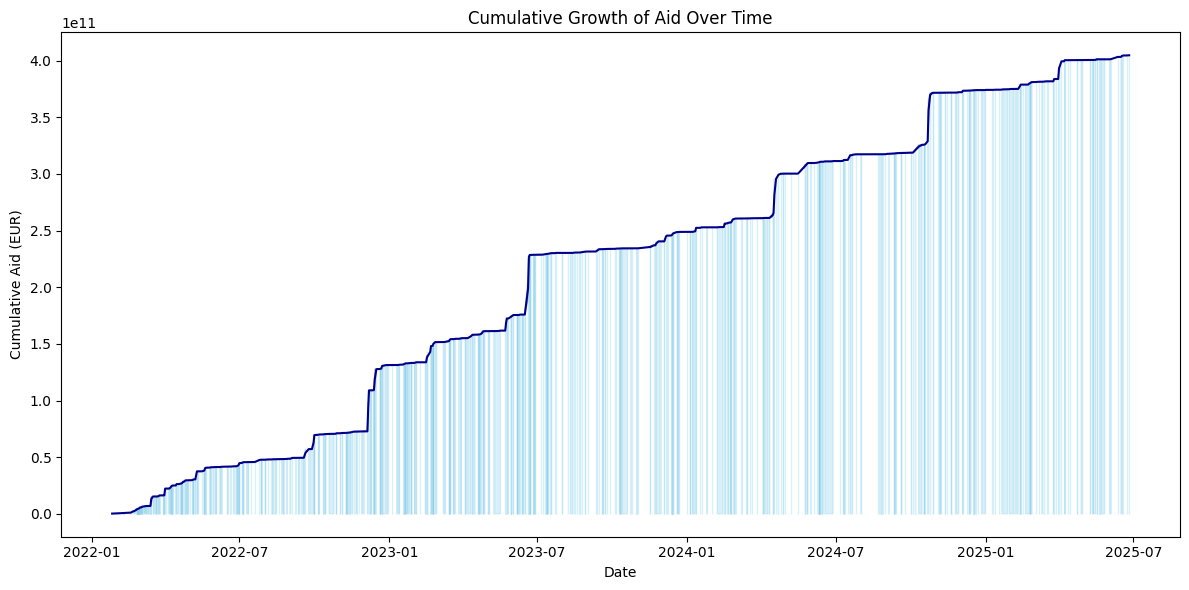

In [48]:
#sort date values
df_clean_sorted = df_clean.sort_values("announcement_date")
df_clean_sorted["cumulative"] = df_clean_sorted["tot_activity_value_EUR"].cumsum()

#plott
plt.figure(figsize=(12,6))
sns.lineplot(data=df_clean_sorted, x="announcement_date", y="cumulative", color="darkblue")
plt.fill_between(df_clean_sorted["announcement_date"], df_clean_sorted["cumulative"], alpha=0.3, color="skyblue")
plt.title("Cumulative Growth of Aid Over Time")
plt.ylabel("Cumulative Aid (EUR)")
plt.xlabel("Date")
plt.tight_layout()
plt.show()

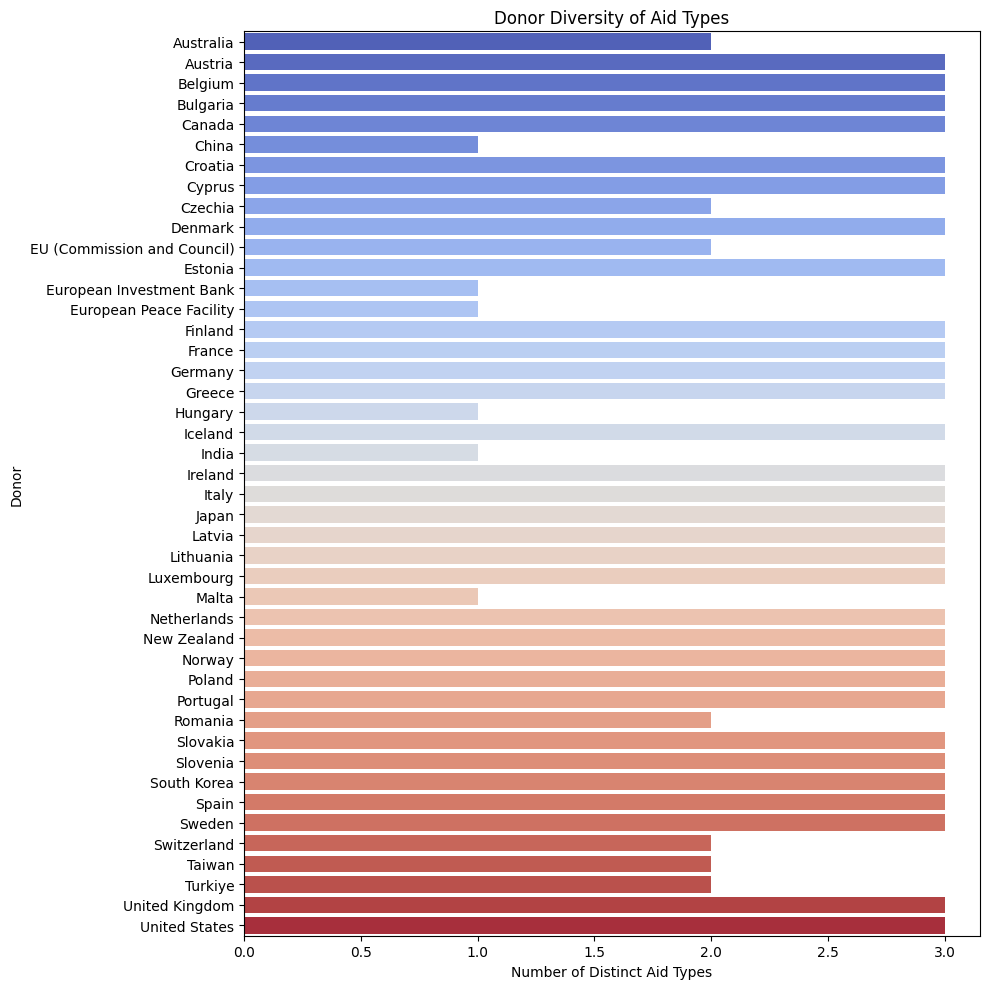

In [49]:
# trying diversity
diversity = df_clean.groupby("donor")["aid_type_general"].nunique().reset_index(name="aid_type_count")
top_div = diversity.nlargest(15, "aid_type_count")

plt.figure(figsize=(10,10))
sns.barplot(data=diversity, x="aid_type_count", y="donor", palette="coolwarm")
plt.title("Donor Diversity of Aid Types")
plt.xlabel("Number of Distinct Aid Types")
plt.ylabel("Donor")
plt.tight_layout()
plt.show()

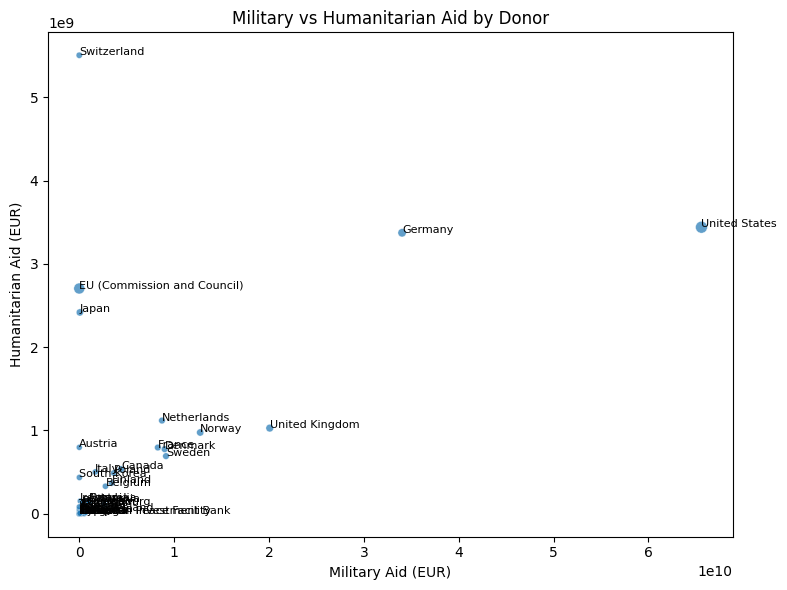

In [50]:
# This is ass
pivot = (
    df_clean.groupby(["donor", "aid_type_general"])["tot_activity_value_EUR"]
    .sum().unstack(fill_value=0)
)

plt.figure(figsize=(8,6))
sns.scatterplot(data=pivot, x="Military", y="Humanitarian", size=pivot.sum(axis=1), legend=False, alpha=0.7)
for donor in pivot.index:
    plt.text(pivot.loc[donor,"Military"], pivot.loc[donor,"Humanitarian"], donor, fontsize=8)
plt.title("Military vs Humanitarian Aid by Donor")
plt.xlabel("Military Aid (EUR)")
plt.ylabel("Humanitarian Aid (EUR)")
plt.tight_layout()
plt.show()

## This is what works

In [51]:
import pandas as pd

# dataset
df = pd.read_csv("/home/aplior/Documents/Programming/Python/ASU-ASSIGNMENTS/Capstone/Data/UST/7fc13150-1dd2-4740-bfd1-6c9de62af18a-Ukraine_Support_Tracker_Release_24 - Bilateral Assistance, MAIN DATA.csv")

# drop empty columns
df = df.dropna(axis=1, how="all")

# Remove irrelevant columns
drop_cols = [col for col in df.columns if "debug" in col.lower() or "dummy" in col.lower()]
df = df.drop(columns=drop_cols)

# clean numeric columns
value_cols = [
    "source_reported_value", 
    "tot_activity_value", "tot_activity_value_EUR",
    "tot_sub_activity_value", "tot_sub_activity_value_EUR",
    "item_value_estimate_USD", "item_value_estimate_deliv_USD"
]

for col in value_cols:
    if col in df.columns:
        df[col] = (
            df[col]
            .astype(str)
            .str.replace(",", "", regex=False)
            .str.strip()
            .replace(["Not given", "Not Given", "Unknown", ""], pd.NA)
        )
        df[col] = pd.to_numeric(df[col], errors="coerce")

# standardize date column
if "announcement_date" in df.columns:
    df["announcement_date"] = pd.to_datetime(df["announcement_date"], errors="coerce")

# keep core analysis
core_cols = [
    "donor", "announcement_date", 
    "aid_type_general", "aid_type_specific",
    "explanation", "item", "item_type", "item_sub_type",
    "source_reported_value", "tot_activity_value_EUR", "item_value_estimate_USD"
]

df_clean = df[[col for col in core_cols if col in df.columns]]
df_clean


,donor,announcement_date,aid_type_general,aid_type_specific,explanation,item,item_type,item_sub_type,source_reported_value,tot_activity_value_EUR,item_value_estimate_USD
0,Australia,2022-03-01,Humanitarian,Equipment,Australia has committed immediate humanitarian...,.,.,.,35000000.0,23417160.0,NaN
1,Australia,2022-03-20,Humanitarian,Equipment,"A shipment of 70,000 tons of thermal coal has ...",ton of coal,Humanitarian,Humanitarian,32600000.0,21811412.0,23030000.0
2,Australia,2022-03-20,Humanitarian,Assistance,The Australian government announced 30 million...,.,.,.,12000000.0,8028741.0,NaN
3,Australia,2022-03-20,Humanitarian,Contribution,The Australian government announced 30 million...,.,.,.,10000000.0,6690617.0,NaN
4,Australia,2022-03-20,Humanitarian,Contribution,The Australian government announced 30 million...,.,.,.,8000000.0,5352494.0,NaN
...,...,...,...,...,...,...,...,...,...,...,...
4903,European Investment Bank,2024-07-22,Financial,Loan,The EIB Group has allocated EUR 86 million in ...,.,.,.,86000000.0,86000000.0,NaN
4904,European Investment Bank,2024-07-22,Financial,Guarantee,the EIB Group approved three partial portfolio...,.,.,.,110000000.0,110000000.0,NaN
4905,European Investment Bank,2024-09-24,Financial,Loan,The European Investment Bank (EIB) and the cit...,.,.,.,50000000.0,50000000.0,NaN
4906,European Investment Bank,2025-05-16,Financial,Loan,The European Investment Bank (EIB) has support...,.,.,.,511000.0,511000.0,NaN


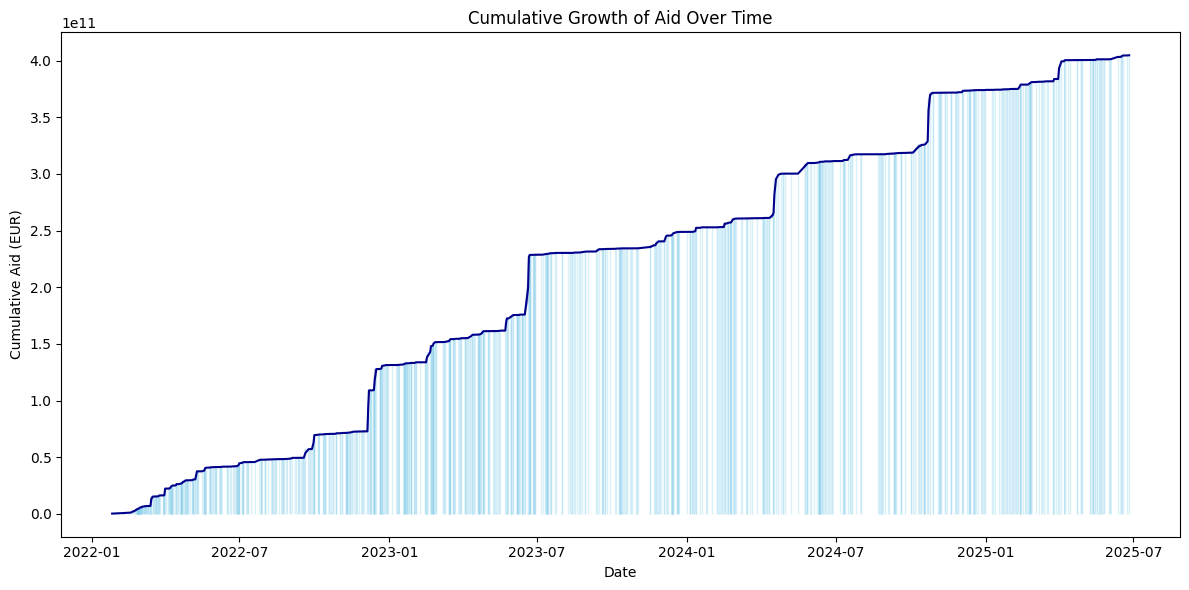

In [52]:
#sort date values
df_clean_sorted = df_clean.sort_values("announcement_date")
df_clean_sorted["cumulative"] = df_clean_sorted["tot_activity_value_EUR"].cumsum()

#plott
plt.figure(figsize=(12,6))
sns.lineplot(data=df_clean_sorted, x="announcement_date", y="cumulative", color="darkblue")
plt.fill_between(df_clean_sorted["announcement_date"], df_clean_sorted["cumulative"], alpha=0.3, color="skyblue")
plt.title("Cumulative Growth of Aid Over Time")
plt.ylabel("Cumulative Aid (EUR)")
plt.xlabel("Date")
plt.tight_layout()
plt.show()